In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
# --- 1️⃣ Load the data ---
csv_path="output/full_benchmark_summary_Jean Zay H100_gpu_p6.csv"
color_map = {"8B": "tab:blue", "70B": "tab:orange", "405B": "tab:red"}
csv_path_obj = Path(csv_path)
output_dir = csv_path_obj.with_suffix("") / "plots_by_dataset"
os.makedirs(output_dir, exist_ok=True)
#csv_name="bug_cpu_offload_importance"

# Comparaison supercalculateur

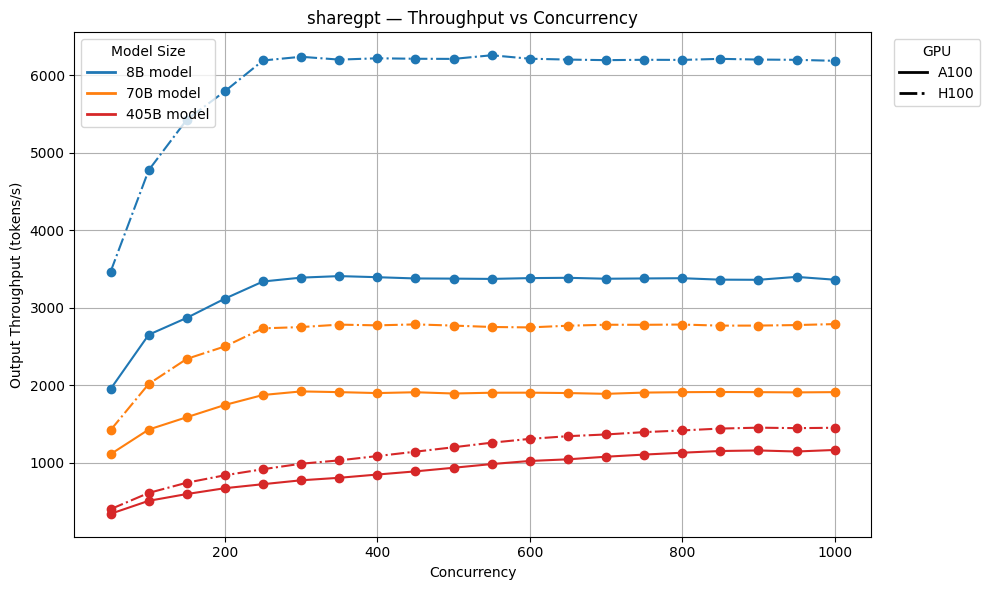

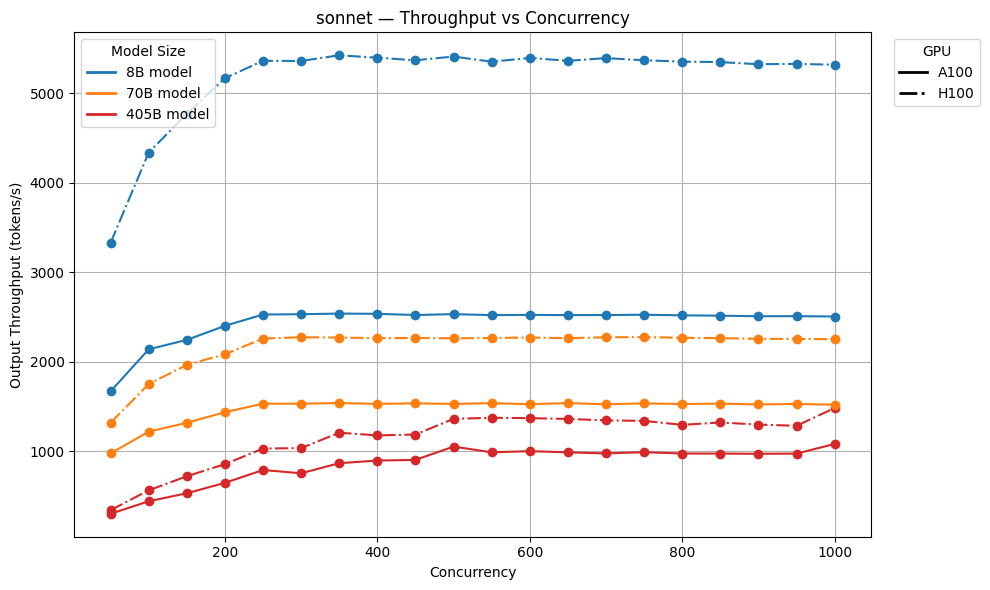

Plots saved to folder: output/full_benchmark_summary_Jean Zay H100_gpu_p6/plots_by_dataset


In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load data
df = pd.read_csv(csv_path)

SUPER_COL = "Supercomputer"
MODEL_COL = "Model"
DATASET_COL = "Dataset"
CONCURRENCY_COL = "Concurrency Level"
THROUGHPUT_COL = "Output Throughput (tokens/s)"

# --- numeric cleanup
df[CONCURRENCY_COL] = pd.to_numeric(df[CONCURRENCY_COL], errors="coerce")
df[THROUGHPUT_COL] = pd.to_numeric(df[THROUGHPUT_COL], errors="coerce")
df = df.dropna(subset=[SUPER_COL, MODEL_COL, DATASET_COL, CONCURRENCY_COL, THROUGHPUT_COL])

df = df.sort_values(by=[DATASET_COL, MODEL_COL, SUPER_COL, CONCURRENCY_COL])

os.makedirs(output_dir, exist_ok=True)

# Consistent model colors
color_map = {"8B": "tab:blue", "70B": "tab:orange", "405B": "tab:red"}

# --- NEW: Extract GPU category (like your first script)
df["GPU"] = df[SUPER_COL].str.extract(r"(A100|V100|H100)", expand=False)
df = df.dropna(subset=["GPU"])

# --- GPU category -> linestyle (so legend shows GPU categories)
accel_order = ["V100", "A100", "H100"]
linestyles = ["--", "-", "-."]  # one per GPU in accel_order
gpu_to_ls = {gpu: ls for gpu, ls in zip(accel_order, linestyles)}

# (Optional) if you ever have other GPU strings, give them a default style
default_ls = ":"

for dataset_name, dataset_df in df.groupby(DATASET_COL):

    plt.figure(figsize=(10, 6))

    # ---- Plot lines
    for (model_name, super_name), group in dataset_df.groupby([MODEL_COL, SUPER_COL]):

        model_size = pd.Series(model_name).str.extract(r"(8B|70B|405B)").iloc[0, 0]
        if model_size not in color_map:
            continue

        gpu = pd.Series(super_name).str.extract(r"(A100|V100|H100)").iloc[0, 0]
        if pd.isna(gpu):
            continue

        group = group.sort_values(CONCURRENCY_COL)

        plt.plot(
            group[CONCURRENCY_COL],
            group[THROUGHPUT_COL],
            marker="o",
            linestyle=gpu_to_ls.get(gpu, default_ls),
            color=color_map[model_size],
        )

    plt.xlabel("Concurrency")
    plt.ylabel("Output Throughput (tokens/s)")
    plt.title(f"{dataset_name} — Throughput vs Concurrency")
    plt.grid(True)

    # ---- Legend 1: Model Size (colors)
    present_sizes = (
        dataset_df[MODEL_COL].str.extract(r"(8B|70B|405B)")[0].dropna().unique().tolist()
    )
    model_legend = [
        Line2D([0], [0], color=color_map[m], lw=2, label=f"{m} model")
        for m in ["8B", "70B", "405B"] if m in present_sizes
    ]

    # ---- Legend 2: GPU category (linestyle) — like your first code’s GPU grouping
    present_gpus = dataset_df["GPU"].dropna().unique().tolist()
    present_gpus = [g for g in accel_order if g in present_gpus] + [g for g in present_gpus if g not in accel_order]

    gpu_legend = [
        Line2D([0], [0], color="black", lw=2, linestyle=gpu_to_ls.get(g, default_ls), label=g)
        for g in present_gpus
    ]

    first_legend = plt.legend(handles=model_legend, title="Model Size", loc="upper left")
    plt.gca().add_artist(first_legend)

    plt.legend(handles=gpu_legend, title="GPU",
               bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    safe_dataset_name = str(dataset_name).replace(" ", "_").replace("/", "_")
    plt.savefig(output_dir / f"{safe_dataset_name}.png", dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

print(f"Plots saved to folder: {output_dir}")


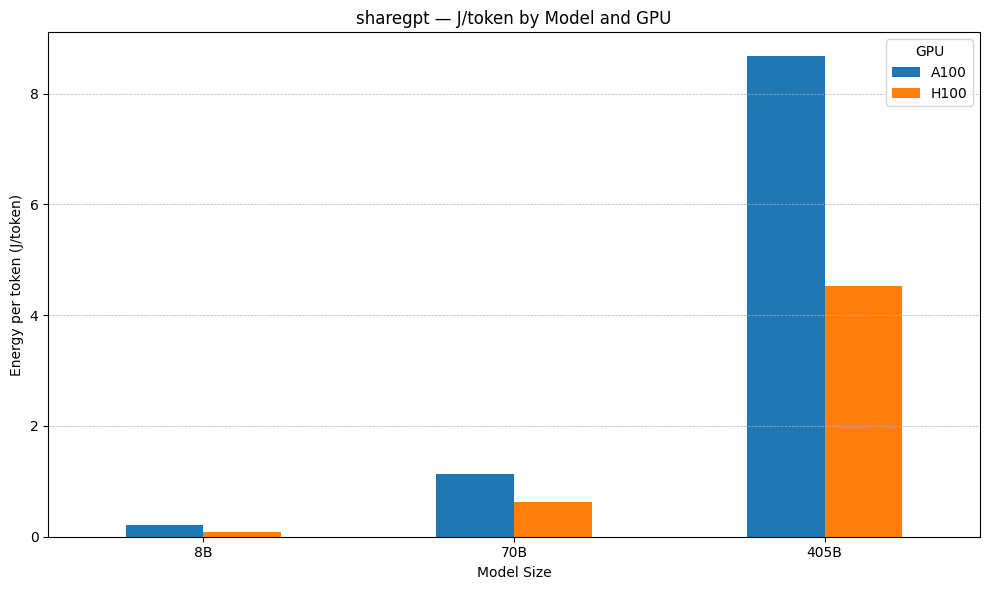

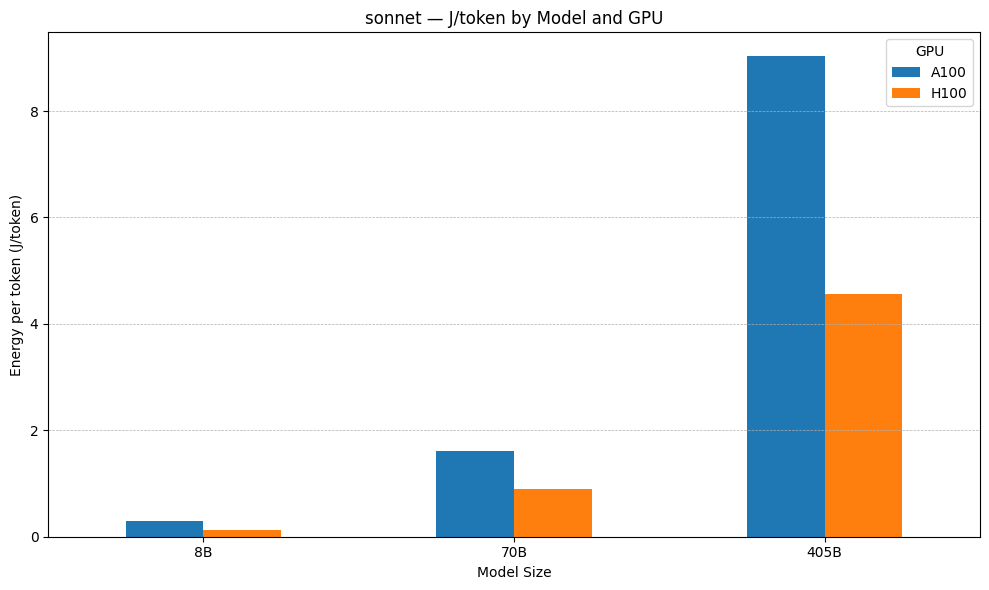

All dataset plots saved to: output/full_benchmark_summary_Jean Zay H100_gpu_p6/plots_by_dataset


In [3]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Inputs you already have
# -----------------------------
# csv_path = Path(".../your_file.csv")
# output_dir = Path(".../plots")
# df = pd.read_csv(csv_path)

SUPER_COL = "Supercomputer"
MODEL_COL = "Model"
DATASET_COL = "Dataset"

POWER_PER_GPU_COL = "Power Usage (W)"
GPU_COL = "Number of GPUs"

THROUGHPUT_COL = "Output Throughput (tokens/s)"  # required to compute J/token

# -----------------------------
# Ensure output folder exists
# -----------------------------
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Ensure numeric + drop bad rows
# -----------------------------
for col in [POWER_PER_GPU_COL, GPU_COL, THROUGHPUT_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[
    SUPER_COL, MODEL_COL, DATASET_COL,
    POWER_PER_GPU_COL, GPU_COL, THROUGHPUT_COL
])

# Remove invalid throughput (avoid division by zero / negatives)
df = df[df[THROUGHPUT_COL] > 0].copy()

# -----------------------------
# Compute Total Power + J/token
# -----------------------------
df["Total Power (W)"] = df[POWER_PER_GPU_COL] * df[GPU_COL]  # W = J/s
df["Joule per Token (J/token)"] = df["Total Power (W)"] / df[THROUGHPUT_COL]

# -----------------------------
# Extract accelerator + model size
# -----------------------------
df["AGPU"] = df[SUPER_COL].str.extract(r"(A100|V100|H100)", expand=False)
df["ModelSize"] = df[MODEL_COL].str.extract(r"(8B|70B|405B)", expand=False)
df = df.dropna(subset=["GPU", "ModelSize", "Joule per Token (J/token)"])

# -----------------------------
# Loop per dataset, plot best (min) J/token by ModelSize & Accelerator
# -----------------------------
for dataset_name, dataset_df in df.groupby(DATASET_COL):

    # Best efficiency = lowest J/token
    agg = (
        dataset_df
        .groupby(["ModelSize", "GPU"], as_index=False)["Joule per Token (J/token)"]
        .min()
    )

    pivot = agg.pivot(index="ModelSize", columns="GPU", values="Joule per Token (J/token)")

    # Order nicely
    size_order = ["8B", "70B", "405B"]
    pivot = pivot.reindex([s for s in size_order if s in pivot.index])

    accel_order = ["V100", "A100", "H100"]
    pivot = pivot[[c for c in accel_order if c in pivot.columns]]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot.plot(kind="bar", ax=ax)

    ax.set_xlabel("Model Size")
    ax.set_ylabel("Energy per token (J/token)")
    ax.set_title(f"{dataset_name} — J/token by Model and GPU")
    ax.grid(axis="y", linestyle="--", linewidth=0.5)

    plt.xticks(rotation=0)
    plt.tight_layout()

    # Save
    safe_name = str(dataset_name).replace(" ", "_").replace("/", "_")
    output_file = output_dir / f"{safe_name}_min_j_per_token.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

print(f"All dataset plots saved to: {output_dir}")


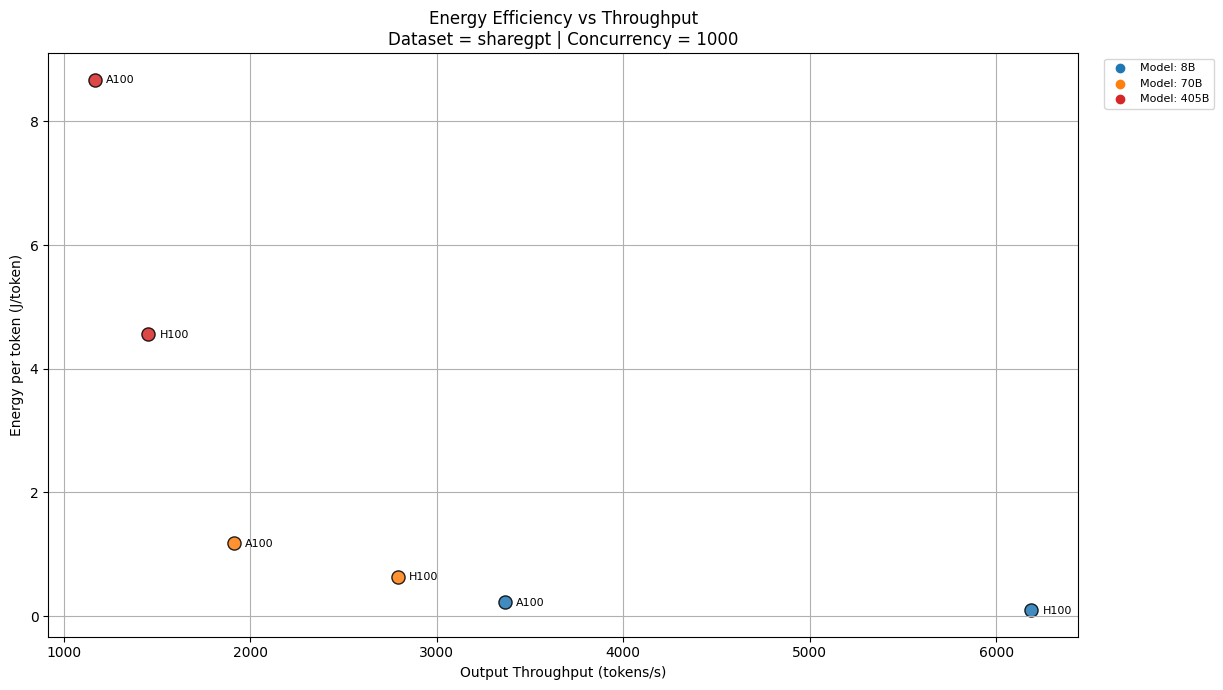

Plot saved to: output/full_benchmark_summary_Jean Zay H100_gpu_p6/plots_by_dataset/j_per_token_vs_throughput_sharegpt_concurrency_1000.png


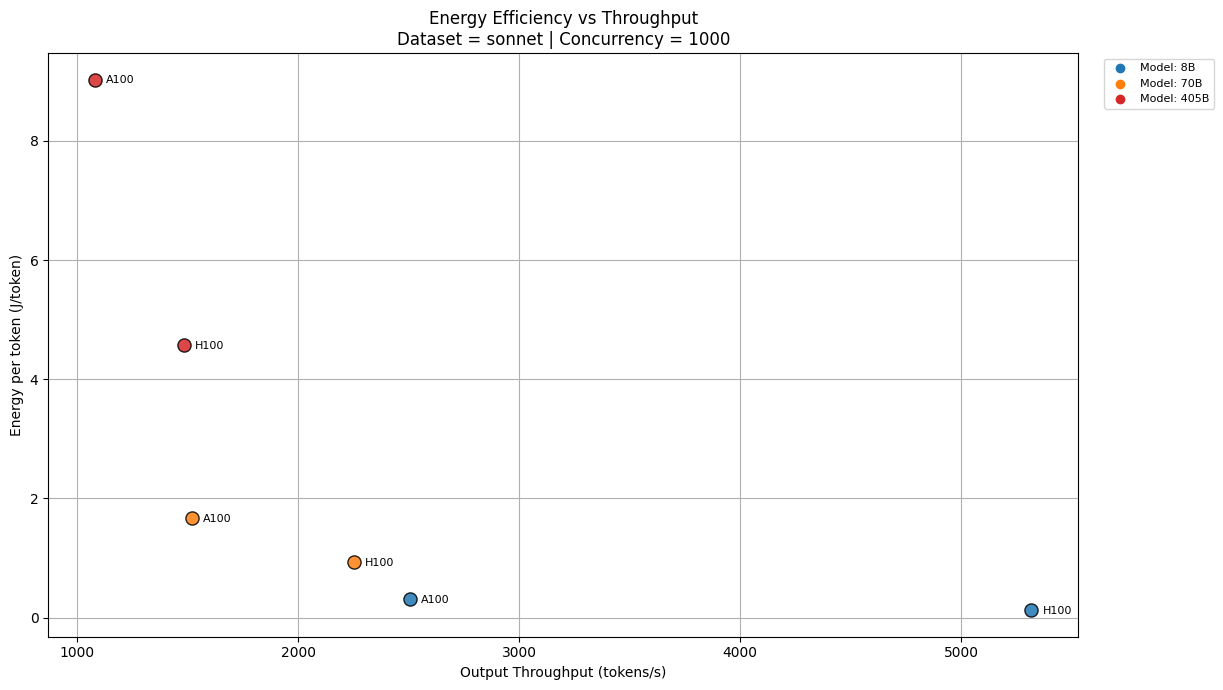

Plot saved to: output/full_benchmark_summary_Jean Zay H100_gpu_p6/plots_by_dataset/j_per_token_vs_throughput_sonnet_concurrency_1000.png


In [4]:
SUPER_COL = "Supercomputer"
MODEL_COL = "Model"
DATASET_COL = "Dataset"
GPU_COL = "Number of GPUs"
POWER_PER_GPU_COL = "Power Usage (W)"
TOKENS_COL = "Output Throughput (tokens/s)"
CONCURRENCY_COL = "Concurrency Level"

# ---- Numeric
for col in [GPU_COL, POWER_PER_GPU_COL, TOKENS_COL, CONCURRENCY_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[
    SUPER_COL, MODEL_COL, DATASET_COL,
    GPU_COL, POWER_PER_GPU_COL, TOKENS_COL, CONCURRENCY_COL
])

# Avoid divide-by-zero
df = df[df[TOKENS_COL] > 0].copy()

# ---- Filter concurrency
df = df[df[CONCURRENCY_COL] == 1000]

# ---- Total system power (W = J/s)
df["Total Power (W)"] = df[POWER_PER_GPU_COL] * df[GPU_COL]

# ---- 🔥 Energy efficiency
df["Joule per Token (J/token)"] = df["Total Power (W)"] / df[TOKENS_COL]

# ---- Extract info
df["ModelSize"] = df[MODEL_COL].str.extract(r"(8B|70B|405B)", expand=False)
df["GPU_Type"] = df[SUPER_COL].str.extract(r"(A100|H100|V100)", expand=False)

df = df.dropna(subset=["ModelSize", "GPU_Type"])

# ---- Visual encodings
dataset_markers = {"sharegpt": "o", "sonnet": "s"}

# ---- Plot points# ---- Dataset loop (one figure per dataset)
for dataset_name, df_dataset in df.groupby(DATASET_COL):

    fig, ax = plt.subplots(figsize=(11, 7))

    # ---- Plot points
    for _, row in df_dataset.iterrows():
        x = row[TOKENS_COL]
        y = row["Joule per Token (J/token)"]

        ax.scatter(
            x, y,
            color=color_map[row["ModelSize"]],
            marker="o",
            edgecolors="black",
            s=90,
            alpha=0.85
        )

        ax.annotate(
            row["GPU_Type"],
            xy=(x, y),
            xytext=(8, -4),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom"
        )

    # ---- Legend (Model sizes only now)
    for size, color in color_map.items():
        ax.scatter([], [], c=color, marker="o", label=f"Model: {size}")

    ax.set_xlabel("Output Throughput (tokens/s)")
    ax.set_ylabel("Energy per token (J/token)")
    ax.set_title(f"Energy Efficiency vs Throughput\nDataset = {dataset_name} | Concurrency = 1000")
    ax.grid(True)

    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

    # ---- Save figure (one file per dataset)
    os.makedirs(output_dir, exist_ok=True)
    output_file = output_dir / f"j_per_token_vs_throughput_{dataset_name}_concurrency_1000.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Plot saved to: {output_file}")
